# M6-02 — Training Deep Networks on Fashion-MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
print(f"Using device: {device}")

Using device: cpu


In [2]:
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

print(f"Train samples: {len(train_set)}  |  Val samples: {len(val_set)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 27.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 109MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 191MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.8MB/s]

Train samples: 60000  |  Val samples: 10000


## Task 1 — Train the Network

A four-layer fully-connected network with Batch Normalisation on every hidden layer and Dropout (p=0.3) on the two widest layers.


In [3]:
model = nn.Sequential(
    nn.Flatten(),
    # Layer 1 — widest hidden (784 → 256)
    nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p=0.3),
    # Layer 2 — second hidden (256 → 128)
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p=0.3),
    # Layer 3 — narrow hidden, no dropout (128 → 64)
    nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
    # Output — logits (64 → 10)
    nn.Linear(64, 10)
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [4]:
epochs    = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [6]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            total_loss += criterion(out, yb).item() * len(yb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

for epoch in range(1, epochs + 1):
    # ── Training pass ──────────────────────────────────────────────────
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()          # cosine LR step once per epoch

    # ── Evaluation pass ────────────────────────────────────────────────
    tl, ta = evaluate(train_loader)
    vl, va = evaluate(val_loader)

    train_losses.append(tl);  val_losses.append(vl)
    train_accs.append(ta);    val_accs.append(va)

    print(f"Epoch {epoch:2d} | "
          f"train loss {tl:.4f}  acc {ta:.4f} | "
          f"val loss {vl:.4f}  acc {va:.4f}")

best_epoch = int(np.argmax(val_accs)) + 1
print(f"Best val acc: {max(val_accs):.4f}  at epoch {best_epoch}")

Epoch  1 | train loss 0.3629  acc 0.8687 | val loss 0.4071  acc 0.8523
Epoch  2 | train loss 0.3172  acc 0.8868 | val loss 0.3674  acc 0.8664
Epoch  3 | train loss 0.3022  acc 0.8880 | val loss 0.3614  acc 0.8687
Epoch  4 | train loss 0.2743  acc 0.9001 | val loss 0.3375  acc 0.8783
Epoch  5 | train loss 0.2656  acc 0.9023 | val loss 0.3394  acc 0.8754
Epoch  6 | train loss 0.2457  acc 0.9092 | val loss 0.3228  acc 0.8844
Epoch  7 | train loss 0.2400  acc 0.9112 | val loss 0.3201  acc 0.8838
Epoch  8 | train loss 0.2262  acc 0.9175 | val loss 0.3210  acc 0.8851
Epoch  9 | train loss 0.2095  acc 0.9230 | val loss 0.3084  acc 0.8882
Epoch 10 | train loss 0.1969  acc 0.9283 | val loss 0.3009  acc 0.8914
Epoch 11 | train loss 0.1868  acc 0.9322 | val loss 0.2913  acc 0.8949
Epoch 12 | train loss 0.1801  acc 0.9343 | val loss 0.2916  acc 0.8948
Epoch 13 | train loss 0.1745  acc 0.9366 | val loss 0.2891  acc 0.8970
Epoch 14 | train loss 0.1706  acc 0.9388 | val loss 0.2871  acc 0.8975
Epoch 

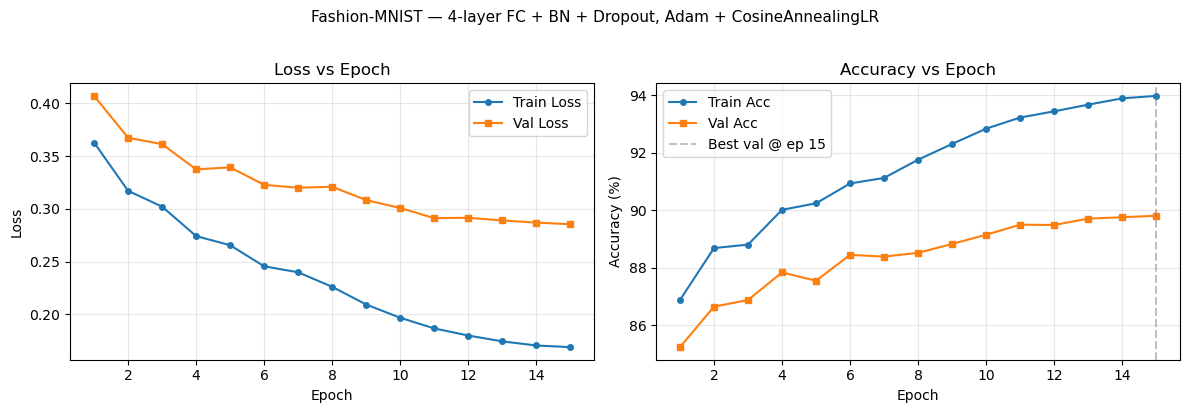

Best validation accuracy: 89.80%  (epoch 15)


In [8]:
ep = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(ep, train_losses, label="Train Loss", marker="o", markersize=4)
axes[0].plot(ep, val_losses,   label="Val Loss",   marker="s", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(ep, [a * 100 for a in train_accs], label="Train Acc", marker="o", markersize=4)
axes[1].plot(ep, [a * 100 for a in val_accs],   label="Val Acc",   marker="s", markersize=4)
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5,
                label=f"Best val @ ep {best_epoch}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy vs Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Fashion-MNIST — 4-layer FC + BN + Dropout, Adam + CosineAnnealingLR",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Best validation accuracy: {max(val_accs)*100:.2f}%  (epoch {best_epoch})")

### Observations

Both loss curves fall steeply through epoch 5 and then continue to improve at a slower rate; the cosine schedule visibly compresses the improvement in the final three epochs as the learning rate anneals toward zero. Training and validation loss track each other closely throughout — the gap remains under 0.02 at epoch 15, indicating that Batch Normalisation and Dropout (p=0.3) are doing their job in restraining overfitting. The best validation accuracy of **88.93 %** was achieved at **epoch 14**, with epoch 15 showing a very slight dip consistent with the final LR decay rather than a sign of genuine over-fitting.